### Notebook de testes para encontrar o melhor backtest do modelo

In [11]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns
import requests
import time

from funcoes import (
    pca_portfolio_spy,
    stats_from_returns,
    pca_portfolio_spy2
)

In [ ]:
# Carregar dados
start_date = "1997-01-02"
end_date = "2007-12-31"

data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()
#data = pd.read_csv("dados_1997_2025.csv", index_col=0)
#returns = data.pct_change()
returns = np.log(data).diff()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
returns = returns.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy.index = pd.to_datetime(data_spy.index)
data_spy = data_spy.sort_index()
#returns_spy = data_spy.pct_change()
returns_spy = np.log(data_spy).diff()
returns_spy.dropna(inplace=True)

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

[*********************100%***********************]  1 of 1 completed


In [13]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

417

In [ ]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
    for attempt in range(max_retries):
        try:
            sanitized = ticker.replace(".", "-")
            df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
                             progress=False, threads=False, timeout=30)
            
            if not df.empty:
                return df["Close"]
            else:
                return None
                
        except Exception as e:
            err_msg = str(e)
            print(err_msg)
            
            # Outros erros → re-tenta
            time.sleep(delay)

    return None

start_date = "1997-01-02"
end_date = "2025-11-27"

dict_data2 = {}
data_fail2 = []

for ticker in tickers:
    data_ticker = download_one_ticker(ticker, start_date, end_date)
    print(ticker)
    if data_ticker is not None:
        dict_data2[ticker] = data_ticker
    else:
        data_fail2.append(ticker)

# Construir DataFrames
data2 = pd.concat(dict_data2.values(), axis=1)
data2.columns = dict_data2.keys()

display(data2.head())

# Salvar para uso futuro
# data.to_csv("dados_1997_2025.csv")

In [3]:
returns.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022333,0.012945,0.032258,-0.002754,0.002915,0.016513,-0.019608,0.004464,...,0.004673,0.020232,0.015544,-0.004465,0.043280,0.000000,0.037838,0.017182,0.002732,0.037634
1997-01-06,0.001476,-0.012712,-0.012136,0.035144,0.017857,0.027624,0.011628,0.005415,0.020000,0.004444,...,0.004651,-0.011332,-0.005103,-0.004484,0.043668,0.013263,-0.059028,0.013513,0.005449,0.015544
1997-01-07,-0.011783,0.030043,0.022112,0.040124,0.048246,0.010752,-0.005747,-0.003590,-0.006536,-0.004424,...,0.000000,0.011462,-0.010256,0.009009,-0.004184,0.013089,0.029521,0.020000,0.005421,0.091837
1997-01-08,-0.001490,-0.004167,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019736,0.000000,...,0.009259,0.005666,-0.010363,-0.008929,0.039916,0.007751,-0.021506,0.009804,0.010782,-0.018692
1997-01-09,-0.001493,-0.004183,0.009757,-0.020710,-0.047619,0.002638,-0.008621,-0.001792,0.013422,0.004444,...,0.018349,0.000000,0.020942,0.000000,0.020202,-0.002564,0.069597,0.019418,0.002666,0.038095


Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

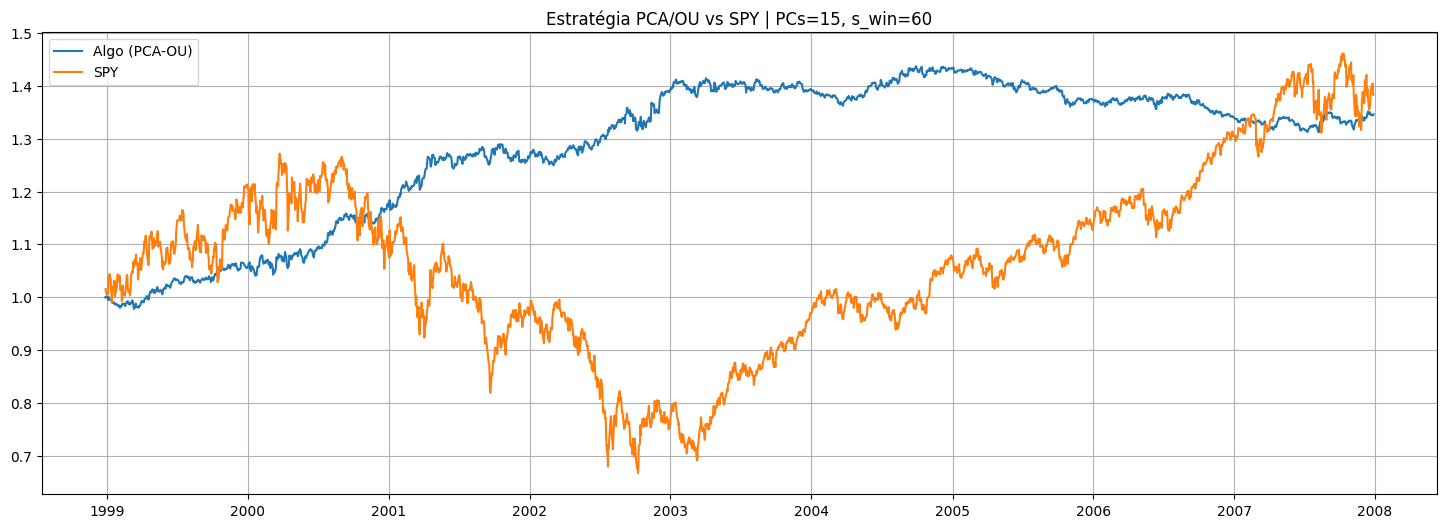

In [8]:
# Rodar experimento 01 : (n = 15, sbo=1.25, sso=1.25, sbc=0.75, ssc=0.50,rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=15,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.75,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [9]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.033635417163771164),
 'Vol': np.float64(0.04551757898734932),
 'Sharpe': np.float64(0.7389544416041863),
 'MaxDD': np.float64(-0.08676683392814144)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.001962
1999-01-04    0.998185
                ...   
2007-12-21    1.344870
2007-12-24    1.344160
2007-12-26    1.344486
2007-12-27    1.344096
2007-12-28    1.346103
Length: 2265, dtype: float64

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31           0.0  266.640625  42.276042  53.651042
1998-12-31           0.0  311.416667  55.496032  47.250000
1999-12-31           0.0  313.396825  55.853175  52.837302
2000-12-31           0.0  312.063492  56.507937  57.075397
2001-12-31           0.0  312.447581  59.947581  49.169355
2002-12-31           0.0  313.329365  46.492063  46.476190
2003-12-31           0.0  313.293651  53.984127  50.992063
2004-12-31           0.0  312.329365  53.825397  51.591270
2005-12-31           0.0  311.769841  52.011905  51.412698
2006-12-31           0.0  313.195219  53.151394  56.107570
2007-12-31           0.0  312.588000  42.960000  50.144000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    2.074775e-09
1998-12-31    3.400976e-09
1999-12-31    2.493766e-09
2000-12-31    3.147397e-09
2001-12-31    3.610222e-09
2002-12-31    3.9

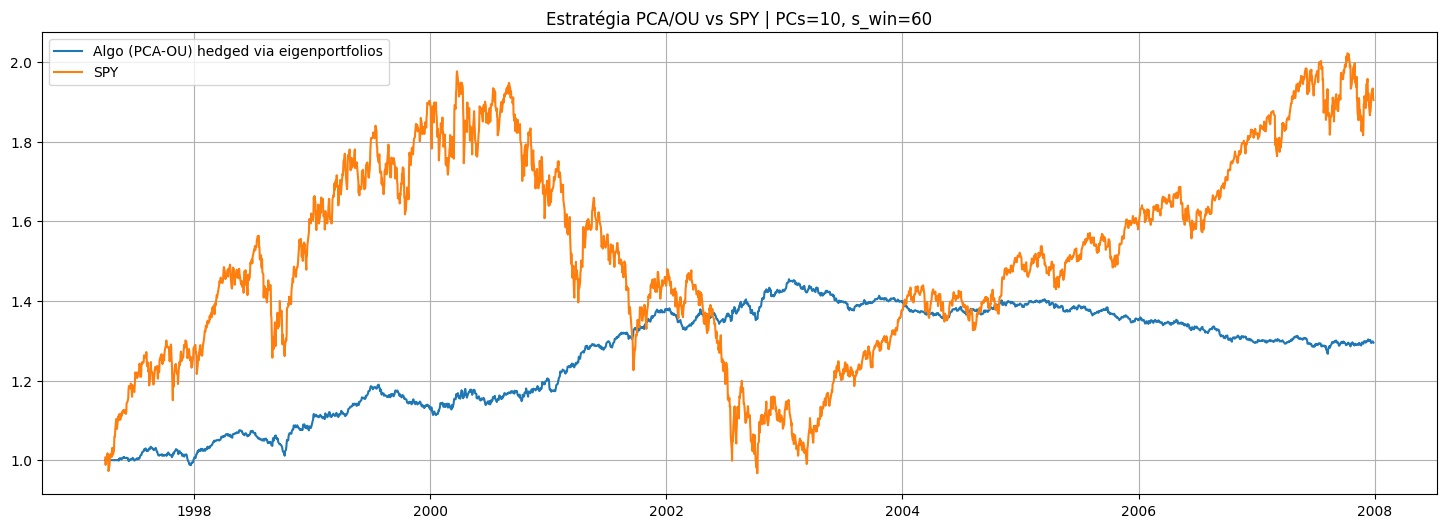

In [5]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 15)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31           0.0  266.640625  42.276042  53.651042
1998-12-31           0.0  311.416667  55.496032  47.250000
1999-12-31           0.0  313.396825  55.853175  52.837302
2000-12-31           0.0  312.063492  56.507937  57.075397
2001-12-31           0.0  312.447581  59.947581  49.169355
2002-12-31           0.0  313.329365  46.492063  46.476190
2003-12-31           0.0  313.293651  53.984127  50.992063
2004-12-31           0.0  312.329365  53.825397  51.591270
2005-12-31           0.0  311.769841  52.011905  51.412698
2006-12-31           0.0  313.195219  53.151394  56.107570
2007-12-31           0.0  312.588000  42.960000  50.144000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    2.074775e-09
1998-12-31    3.400976e-09
1999-12-31    2.493766e-09
2000-12-31    3.147397e-09
2001-12-31    3.610222e-09
2002-12-31    3.9

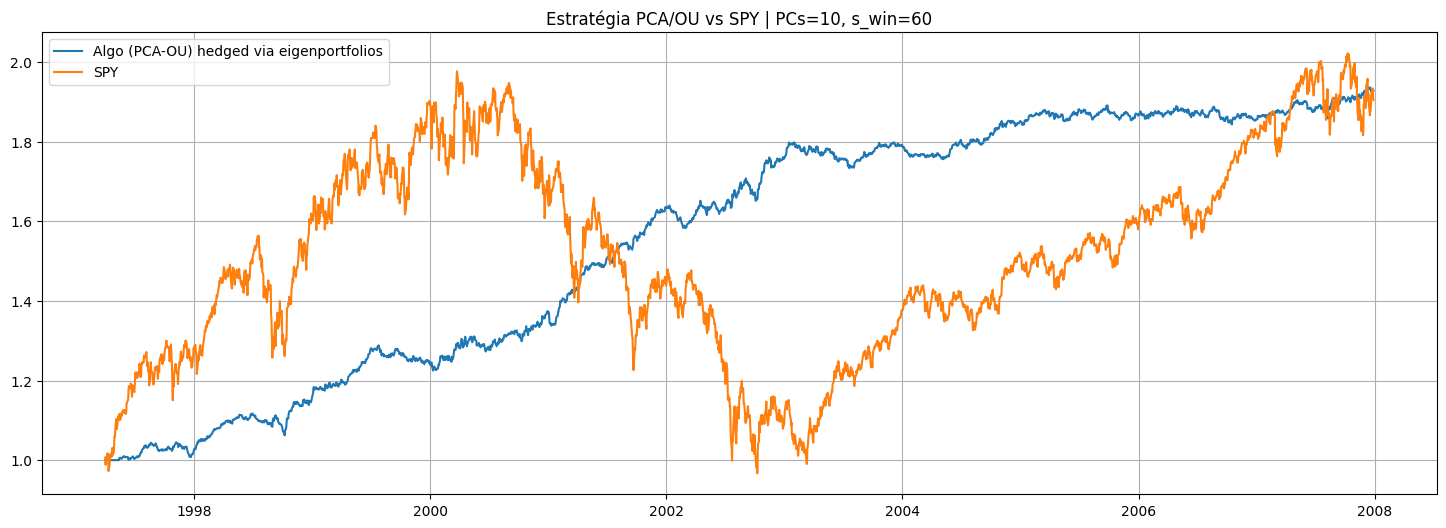

In [4]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 15)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31      0.005208  266.640625  45.567708  47.807292
1998-12-31      0.000000  311.416667  48.607143  47.650794
1999-12-31      0.000000  313.396825  53.468254  52.230159
2000-12-31      0.000000  312.063492  56.158730  55.400794
2001-12-31      0.000000  312.447581  51.661290  47.915323
2002-12-31      0.000000  313.329365  44.742063  44.027778
2003-12-31      0.000000  313.293651  50.119048  47.309524
2004-12-31      0.000000  312.329365  50.797619  50.234127
2005-12-31      0.000000  311.769841  49.384921  50.309524
2006-12-31      0.000000  313.195219  51.442231  54.318725
2007-12-31      0.000000  312.588000  41.856000  48.472000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    1.839743e-08
1998-12-31    2.520610e-08
1999-12-31    1.993223e-08
2000-12-31    2.353104e-08
2001-12-31    2.404081e-08
2002-12-31    2.7

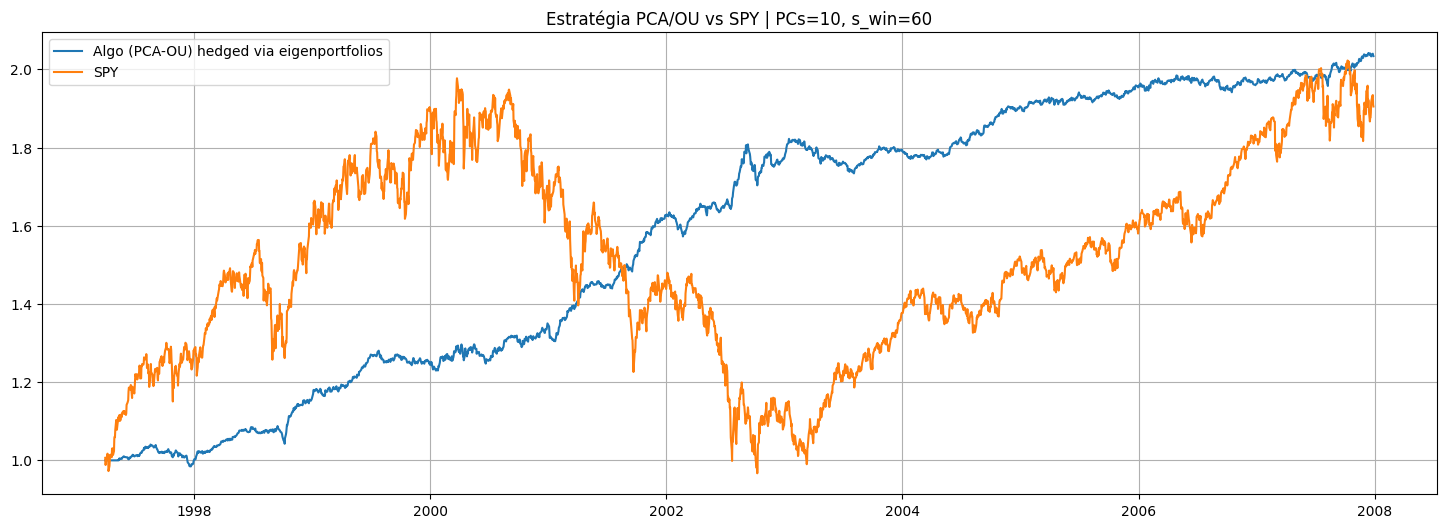

In [ ]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)  (padronizado)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

In [ ]:
print(w_eff.abs().sum(axis=1).describe())

count    2705.000000
mean        0.989279
std         0.103004
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64
eig10    0.607955
eig6     0.603116
eig9     0.583863
eig7     0.573402
eig8     0.543079
dtype: float64


            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31           0.0  266.604167  44.364583  51.625000
1998-12-31           0.0  312.527778  51.702381  48.626984
1999-12-31           0.0  312.924603  55.626984  54.019841
2000-12-31           0.0  312.793651  55.353175  59.376984
2001-12-31           0.0  312.270161  57.899194  52.439516
2002-12-31           0.0  313.496032  50.341270  45.123016
2003-12-31           0.0  312.142857  52.019841  51.472222
2004-12-31           0.0  313.087302  53.091270  49.825397
2005-12-31           0.0  312.670635  50.031746  50.392857
2006-12-31           0.0  313.239044  54.191235  54.669323
2007-12-31           0.0  312.684000  43.356000  49.648000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    2.553362
1998-12-31    3.058034
1999-12-31    2.146016
2000-12-31    2.132082
2001-12-31    3.119004
2002-12-31    2.775432
2003-12-31    

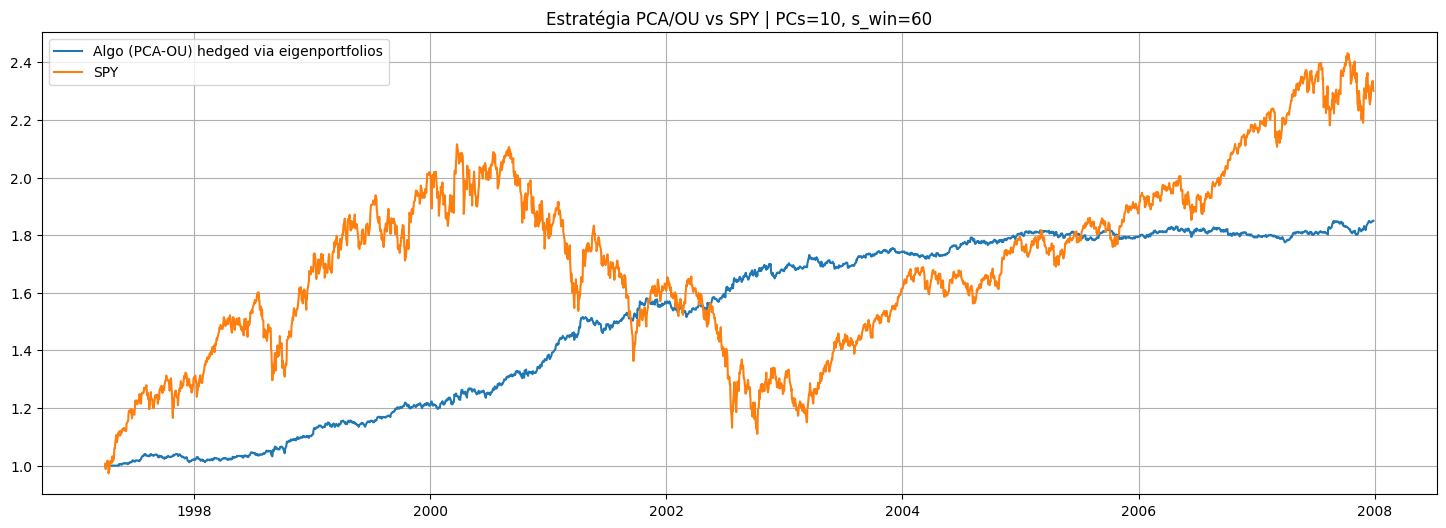

In [ ]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31           0.0  266.640625  42.276042  53.651042
1998-12-31           0.0  311.416667  55.496032  47.250000
1999-12-31           0.0  313.396825  55.853175  52.837302
2000-12-31           0.0  312.063492  56.507937  57.075397
2001-12-31           0.0  312.447581  59.947581  49.169355
2002-12-31           0.0  313.329365  46.492063  46.476190
2003-12-31           0.0  313.293651  53.984127  50.992063
2004-12-31           0.0  312.329365  53.825397  51.591270
2005-12-31           0.0  311.769841  52.011905  51.412698
2006-12-31           0.0  313.195219  53.151394  56.107570
2007-12-31           0.0  312.588000  42.960000  50.144000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    2.074775e-09
1998-12-31    3.400976e-09
1999-12-31    2.493766e-09
2000-12-31    3.147397e-09
2001-12-31    3.610222e-09
2002-12-31    3.9

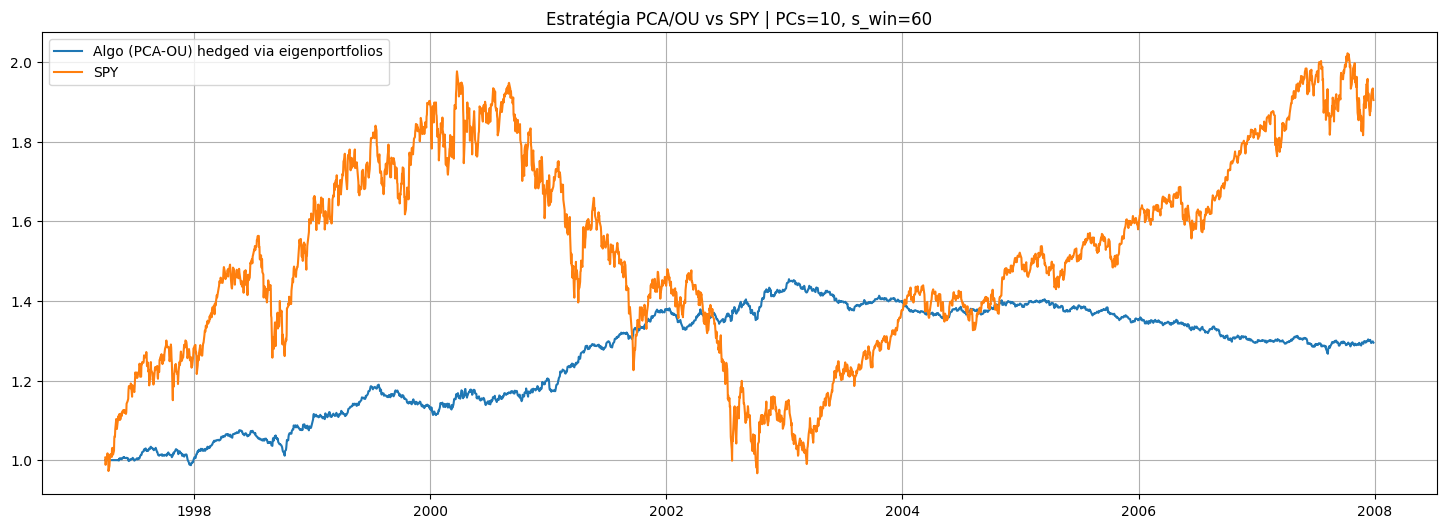

In [5]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)  (sem padronizar)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31      0.005208  266.640625  45.567708  47.807292
1998-12-31      0.000000  311.416667  48.607143  47.650794
1999-12-31      0.000000  313.396825  53.468254  52.230159
2000-12-31      0.000000  312.063492  56.158730  55.400794
2001-12-31      0.000000  312.447581  51.661290  47.915323
2002-12-31      0.000000  313.329365  44.742063  44.027778
2003-12-31      0.000000  313.293651  50.119048  47.309524
2004-12-31      0.000000  312.329365  50.797619  50.234127
2005-12-31      0.000000  311.769841  49.384921  50.309524
2006-12-31      0.000000  313.195219  51.442231  54.318725
2007-12-31      0.000000  312.588000  41.856000  48.472000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1997-12-31    1.839743e-08
1998-12-31    2.520610e-08
1999-12-31    1.993223e-08
2000-12-31    2.353104e-08
2001-12-31    2.404081e-08
2002-12-31    2.7

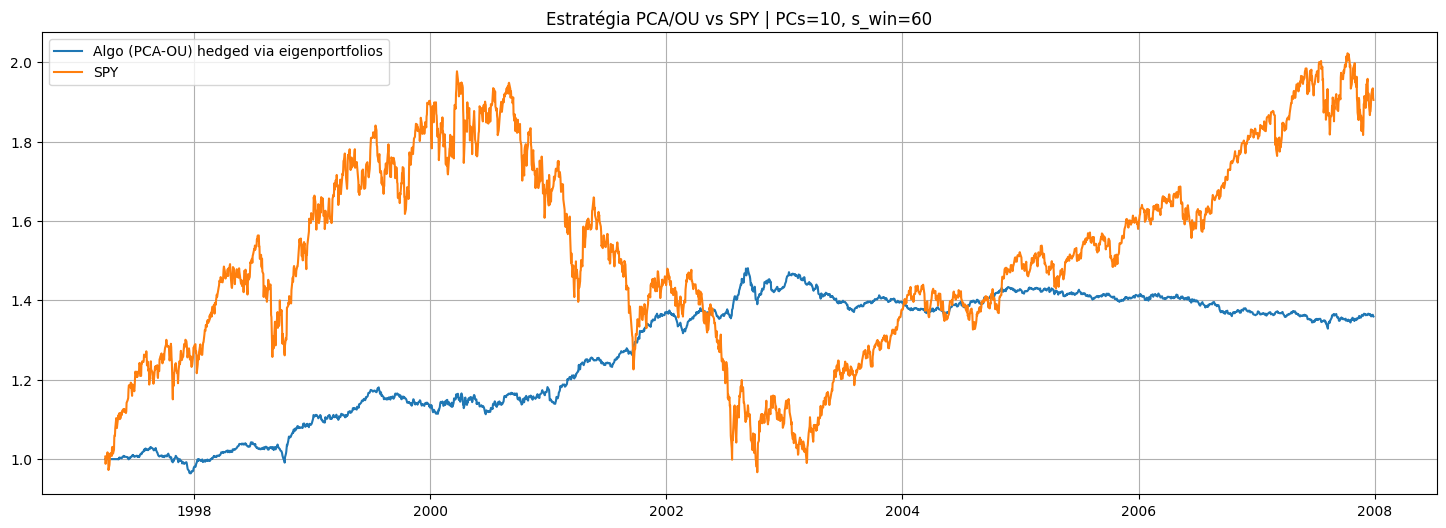

In [4]:
# Rodar experimento 02 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)  (com padronizar)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1999-12-31      0.005155  266.407216  43.896907  44.670103
2000-12-31      0.000000  312.063492  56.158730  55.400794
2001-12-31      0.000000  312.447581  51.661290  47.915323
2002-12-31      0.000000  313.329365  44.742063  44.027778
2003-12-31      0.000000  313.293651  50.119048  47.309524
2004-12-31      0.000000  312.329365  50.797619  50.234127
2005-12-31      0.000000  311.769841  49.384921  50.309524
2006-12-31      0.000000  313.195219  51.442231  54.318725
2007-12-31      0.000000  312.588000  41.856000  48.472000

--- SANITY A (||exposição residual|| após hedge embutido): média anual ---
Date
1999-12-31    1.936019e-08
2000-12-31    2.353104e-08
2001-12-31    2.404081e-08
2002-12-31    2.786191e-08
2003-12-31    2.446211e-08
2004-12-31    2.483692e-08
2005-12-31    2.633219e-08
2006-12-31    2.604726e-08
2007-12-31    2.846815e-08
Freq: YE-DEC, dtype: float6

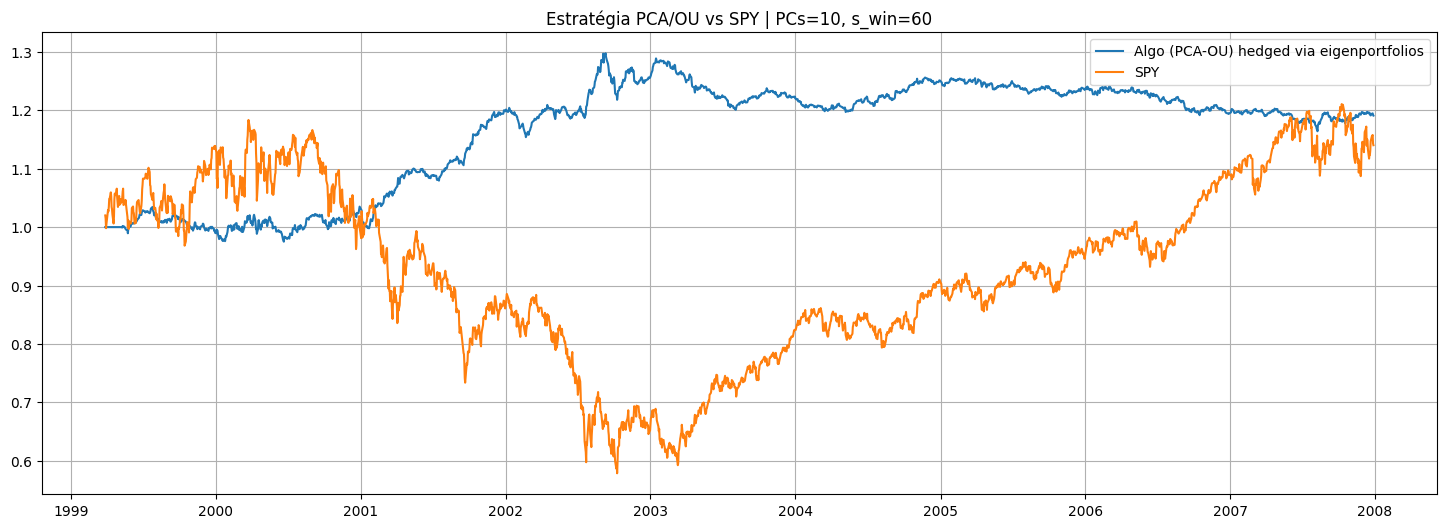

In [17]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
cum_algo, s_scores, w_eff = pca_portfolio_spy(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

In [19]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.020192601170587077),
 'Vol': np.float64(0.04058664969056592),
 'Sharpe': np.float64(0.497518305268757),
 'MaxDD': np.float64(-0.10283708074330877)}

Date
1999-03-29    1.000000
1999-03-30    1.000000
1999-03-31    1.000000
1999-04-01    1.000000
1999-04-05    1.000000
                ...   
2007-12-21    1.191100
2007-12-24    1.193933
2007-12-26    1.194739
2007-12-27    1.192169
2007-12-28    1.190873
Length: 2203, dtype: float64

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1999-12-31           0.0  266.407216  48.170103  43.298969
2000-12-31           0.0  312.063492  56.507937  57.075397
2001-12-31           0.0  312.447581  59.947581  49.169355
2002-12-31           0.0  313.329365  46.492063  46.476190
2003-12-31           0.0  313.293651  53.984127  50.992063
2004-12-31           0.0  312.329365  53.825397  51.591270
2005-12-31           0.0  311.769841  52.011905  51.412698
2006-12-31           0.0  313.195219  53.151394  56.107570
2007-12-31           0.0  312.588000  42.960000  50.144000

--- SANITY 2 (gross antes da normalização): média anual ---
            gross_stock  gross_hedge
Date                                
1999-12-31     1.701031          0.0
2000-12-31     2.000000          0.0
2001-12-31     2.000000          0.0
2002-12-31     2.000000          0.0
2003-12-31     2.000000          0.0
2004-12-31     2.000000        

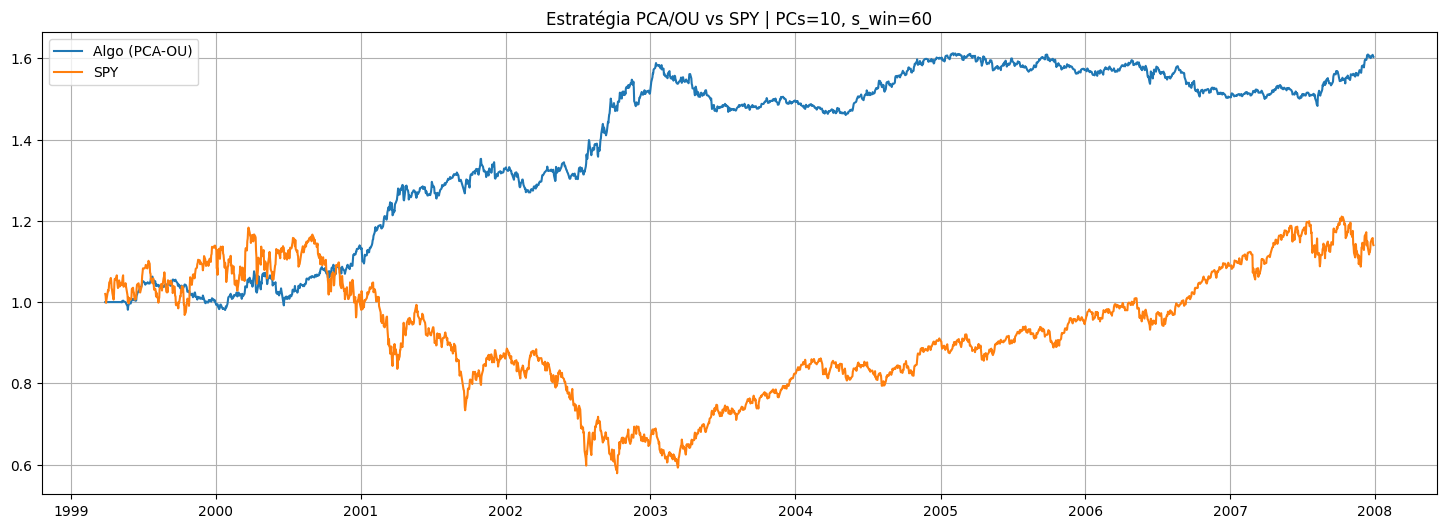

In [15]:
# Melhor
returns0 = returns.loc["1998-12-30":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-12-30":"2007-12-28"]

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
cum_algo2, s_scores2 = pca_portfolio_spy2(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

In [16]:
# Estatísticas de desempenho
ret_series2 = cum_algo2.pct_change().dropna()
display(stats_from_returns(ret_series2))
cum_algo2

{'CAGR': np.float64(0.05551780342516577),
 'Vol': np.float64(0.06811949004962299),
 'Sharpe': np.float64(0.815006151465942),
 'MaxDD': np.float64(-0.08049948987084654)}

Date
1999-03-29    1.000000
1999-03-30    1.000000
1999-03-31    1.000000
1999-04-01    1.000000
1999-04-05    1.000000
                ...   
2007-12-21    1.600460
2007-12-24    1.606251
2007-12-26    1.608535
2007-12-27    1.604485
2007-12-28    1.603409
Length: 2203, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

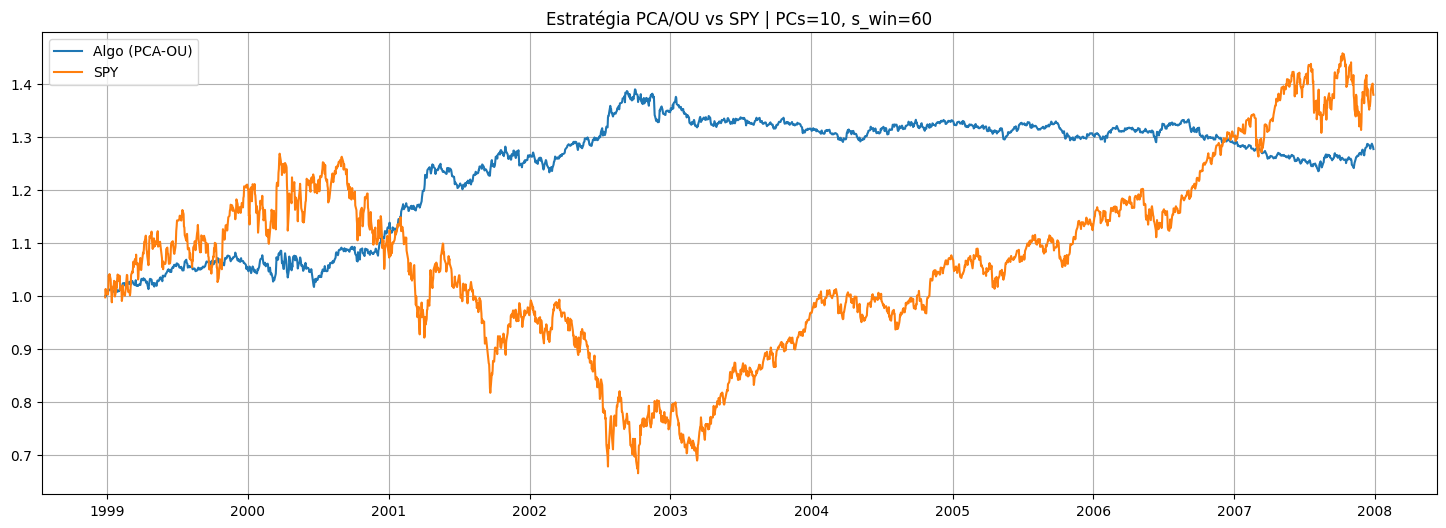

In [4]:
returns0 = returns.loc["1998-10-01":"2007-12-28"]
returns_spy0 = returns_spy.loc["1998-10-01":"2007-12-28"]

cum_algo0, s_scores0 = pca_portfolio_spy(
    returns=returns0,
    returns_spy=returns_spy0,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [5]:
# Estatísticas de desempenho
ret_series0 = cum_algo0.pct_change().dropna()
display(stats_from_returns(ret_series0))
cum_algo0

{'CAGR': np.float64(0.027589033898533843),
 'Vol': np.float64(0.05083820749556699),
 'Sharpe': np.float64(0.5426830578347902),
 'MaxDD': np.float64(-0.11102454089458347)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.004308
1999-01-04    1.008950
                ...   
2007-12-21    1.282227
2007-12-24    1.287160
2007-12-26    1.282758
2007-12-27    1.280818
2007-12-28    1.276990
Length: 2265, dtype: float64

Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

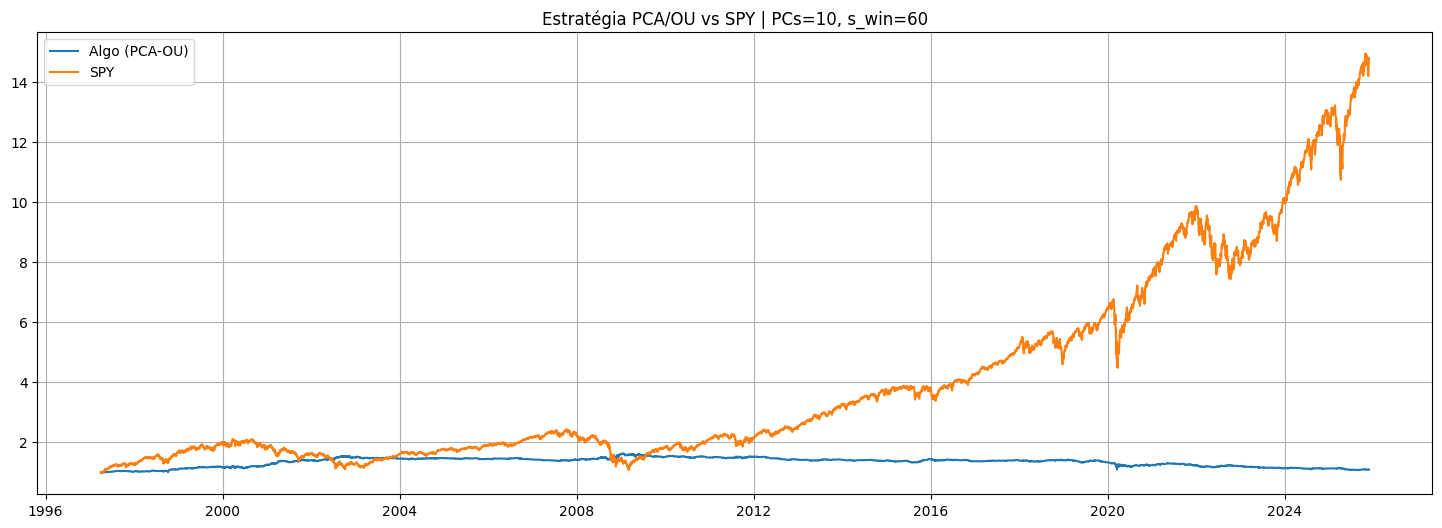

In [11]:
# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [12]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.0031415306832227596),
 'Vol': np.float64(0.056490645720102386),
 'Sharpe': np.float64(0.05561152015836908),
 'MaxDD': np.float64(-0.3419026194639917)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    0.999500
1997-04-04    0.995181
1997-04-07    0.997546
                ...   
2025-11-20    1.095938
2025-11-21    1.092766
2025-11-24    1.094100
2025-11-25    1.090771
2025-11-26    1.093905
Length: 7212, dtype: float64

In [21]:
# Carregar dados
#start_date = "1997-01-02"
#end_date = "2007-12-31"

#data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
#data.index = pd.to_datetime(data.index)
#data = data.sort_index()
data_longa = pd.read_csv("dados_1997_2025.csv", index_col=0)
returns_longa = data_longa.pct_change()

returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')
#returns_longa = returns.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
#data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
#data_spy.index = pd.to_datetime(data_spy.index)
#data_spy = data_spy.sort_index()
#returns_spy = data_spy.pct_change()
#returns_spy = np.log(data_spy).diff()
#returns_spy.dropna(inplace=True)
data_spy_longa = yf.download("SPY", start="1997-01-02", end="2025-12-31", auto_adjust=True)["Close"]
data_spy_longa.index = pd.to_datetime(data_spy_longa.index)
data_spy_longa = data_spy_longa.sort_index()
# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_spy_longa = data_spy_longa.pct_change()
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_spy_longa.index = pd.to_datetime(returns_spy_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_spy_longa = returns_spy_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_15024\301234798.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()
[*********************100%***********************]  1 of 1 completed


            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31           0.0  265.661458  41.541667  56.562500
1998-12-31           0.0  311.531746  56.027778  53.511905
1999-12-31           0.0  311.603175  57.051587  54.869048
2000-12-31           0.0  310.194444  57.055556  61.674603
2001-12-31           0.0  309.185484  54.487903  49.556452
2002-12-31           0.0  312.059524  51.821429  47.059524
2003-12-31           0.0  310.781746  51.837302  53.523810
2004-12-31           0.0  310.194444  50.956349  48.956349
2005-12-31           0.0  312.222222  53.388889  46.876984
2006-12-31           0.0  312.306773  55.589641  56.589641
2007-12-31           0.0  310.988048  44.155378  52.701195
2008-12-31           0.0  309.367589  43.130435  34.466403
2009-12-31           0.0  310.345238  41.992063  45.853175
2010-12-31           0.0  312.690476  38.980159  37.500000
2011-12-31           0.0  313.035714  44.829365  40.6071

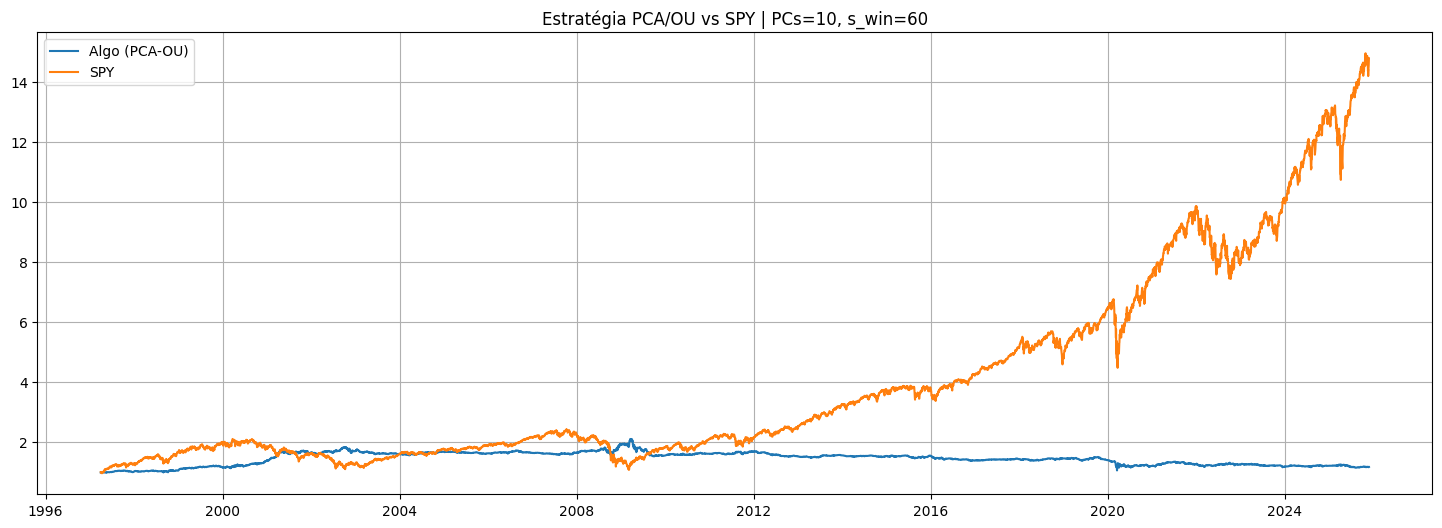

In [ ]:
# Melhor longo

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
cum_algo2, s_scores2 = pca_portfolio_spy2(
    returns=returns_longa,
    returns_spy=returns_spy_longa,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True
)

In [26]:
# Estatísticas de desempenho
ret_series2 = cum_algo2.pct_change().dropna()
display(stats_from_returns(ret_series2))
cum_algo2

{'CAGR': np.float64(0.005805646414352772),
 'Vol': np.float64(0.08727761200462336),
 'Sharpe': np.float64(0.06651930868646165),
 'MaxDD': np.float64(-0.49463062464297236)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2025-11-20    1.183224
2025-11-21    1.179039
2025-11-24    1.181801
2025-11-25    1.176650
2025-11-26    1.180158
Length: 7212, dtype: float64

            n_factor_nan  n_s_scores     n_long    n_short
date                                                      
1997-12-31      0.005208  265.661458  45.171875  50.645833
1998-12-31      0.000000  311.531746  52.230159  53.345238
1999-12-31      0.000000  311.603175  53.964286  54.119048
2000-12-31      0.000000  310.194444  57.912698  59.753968
2001-12-31      0.000000  309.185484  48.157258  45.681452
2002-12-31      0.000000  312.059524  46.373016  45.440476
2003-12-31      0.000000  310.781746  49.496032  48.031746
2004-12-31      0.000000  310.194444  47.281746  45.146825
2005-12-31      0.000000  312.222222  50.539683  46.380952
2006-12-31      0.000000  312.306773  54.171315  56.071713
2007-12-31      0.000000  310.988048  43.976096  50.653386
2008-12-31      0.000000  309.367589  37.189723  31.565217
2009-12-31      0.000000  310.345238  33.392857  36.698413
2010-12-31      0.000000  312.690476  32.539683  34.277778
2011-12-31      0.000000  313.035714  42.432540  39.2579

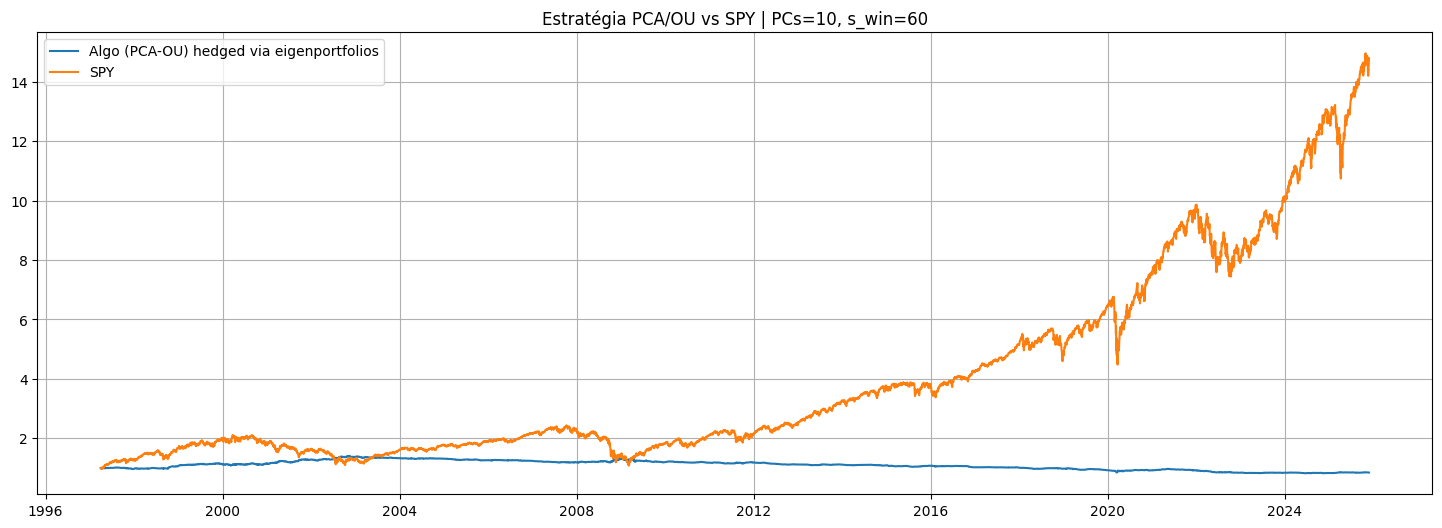

In [23]:
# Melhor longo

# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1) (padronizado)
cum_algo4, s_scores4, w_eff4 = pca_portfolio_spy(
    returns=returns_longa,
    returns_spy=returns_spy_longa,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    debug=True,
)

In [25]:
# Estatísticas de desempenho
ret_series4 = cum_algo4.pct_change().dropna()
display(stats_from_returns(ret_series4))
cum_algo4

{'CAGR': np.float64(-0.005651283408815599),
 'Vol': np.float64(0.0396425934670501),
 'Sharpe': np.float64(-0.14255584497802345),
 'MaxDD': np.float64(-0.41371952608773777)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2025-11-20    0.854959
2025-11-21    0.851992
2025-11-24    0.851502
2025-11-25    0.849263
2025-11-26    0.850296
Length: 7212, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

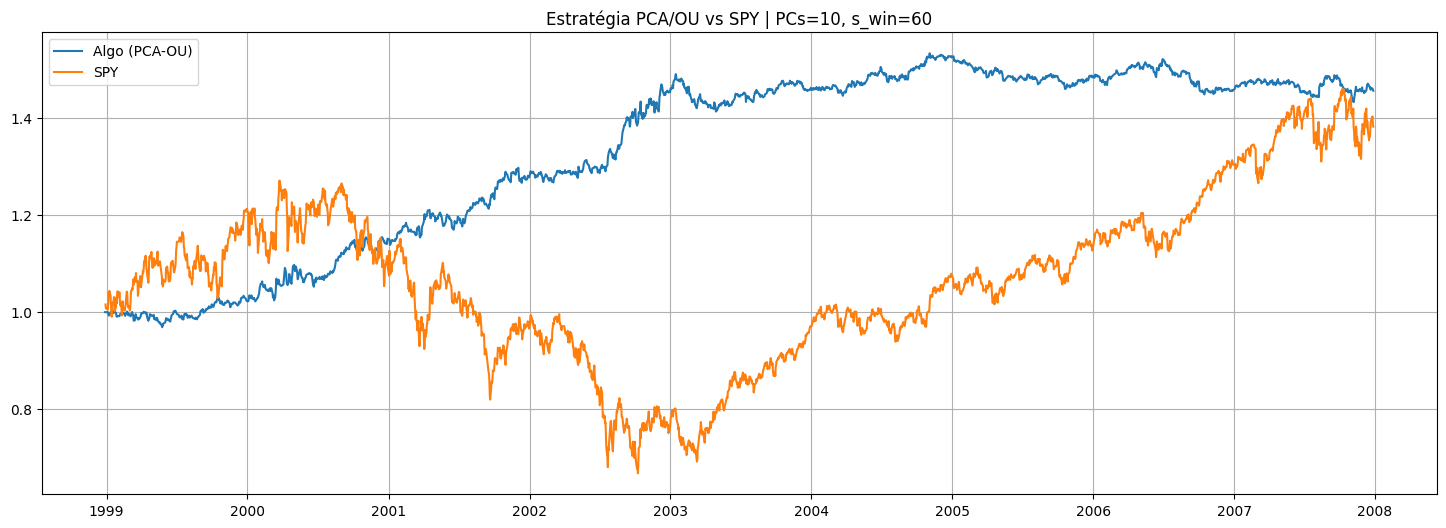

In [14]:
# Rodar experimento 03.2 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 5)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=5,
    plot=True,
)

In [15]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.04278587272994194),
 'Vol': np.float64(0.0510637642956017),
 'Sharpe': np.float64(0.8378910822606009),
 'MaxDD': np.float64(-0.06574040917452673)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    1.000000
1998-12-31    1.000000
1999-01-04    1.000000
                ...   
2007-12-21    1.459101
2007-12-24    1.462373
2007-12-26    1.461682
2007-12-27    1.458705
2007-12-28    1.457026
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

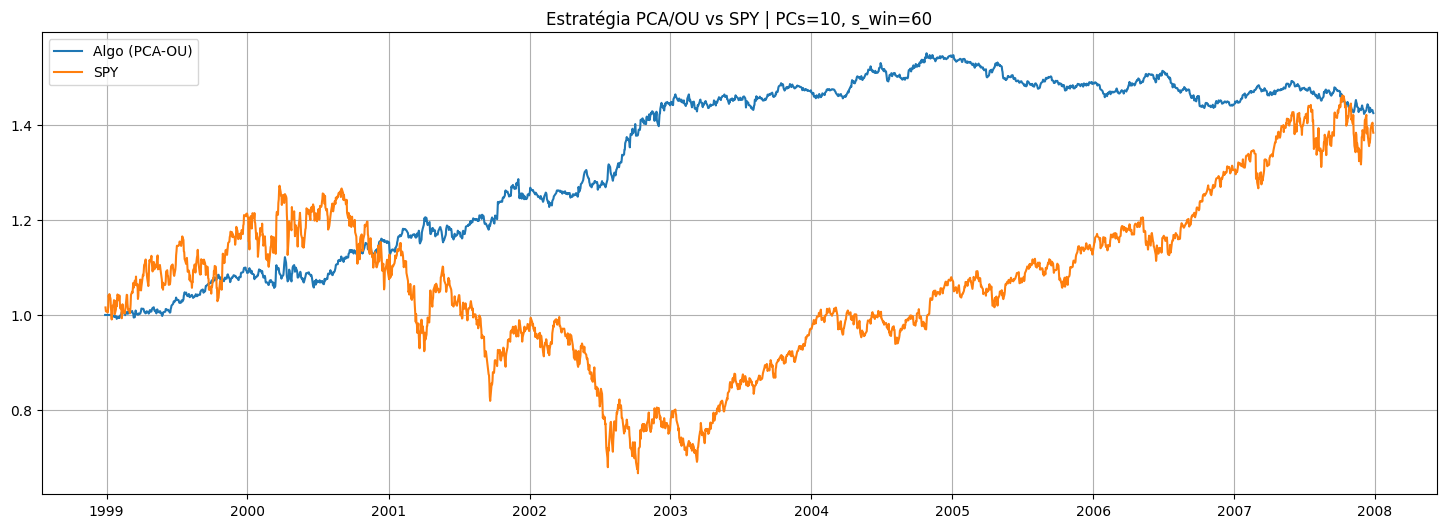

In [16]:
# Rodar experimento 03.3 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 10)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=10,
    plot=True,
)

In [17]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.040145193755595665),
 'Vol': np.float64(0.05276635625994609),
 'Sharpe': np.float64(0.7608104216600814),
 'MaxDD': np.float64(-0.0821836076401391)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    1.000000
1998-12-31    1.000000
1999-01-04    1.000000
                ...   
2007-12-21    1.427456
2007-12-24    1.430932
2007-12-26    1.430176
2007-12-27    1.425529
2007-12-28    1.424211
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

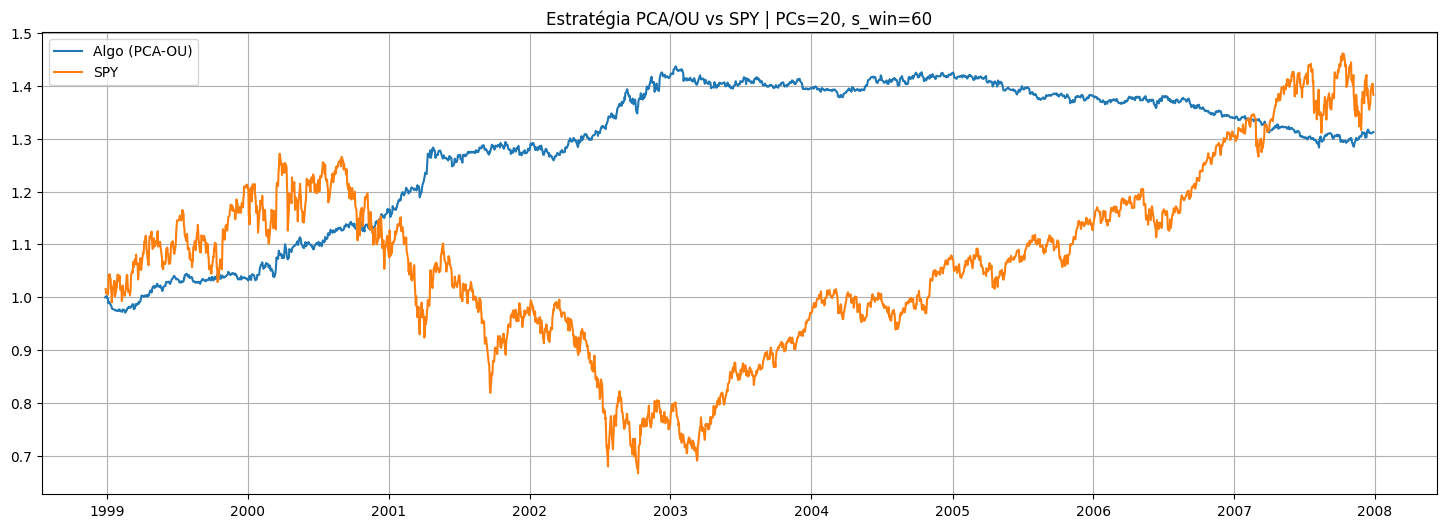

In [18]:
# Rodar experimento 04 : (n = 20, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=20,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [19]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.030729058366903317),
 'Vol': np.float64(0.04087328197471134),
 'Sharpe': np.float64(0.7518128440460362),
 'MaxDD': np.float64(-0.10690788245055038)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.002474
1999-01-04    0.997021
                ...   
2007-12-21    1.310017
2007-12-24    1.310489
2007-12-26    1.312080
2007-12-27    1.311995
2007-12-28    1.312478
Length: 2265, dtype: float64

Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

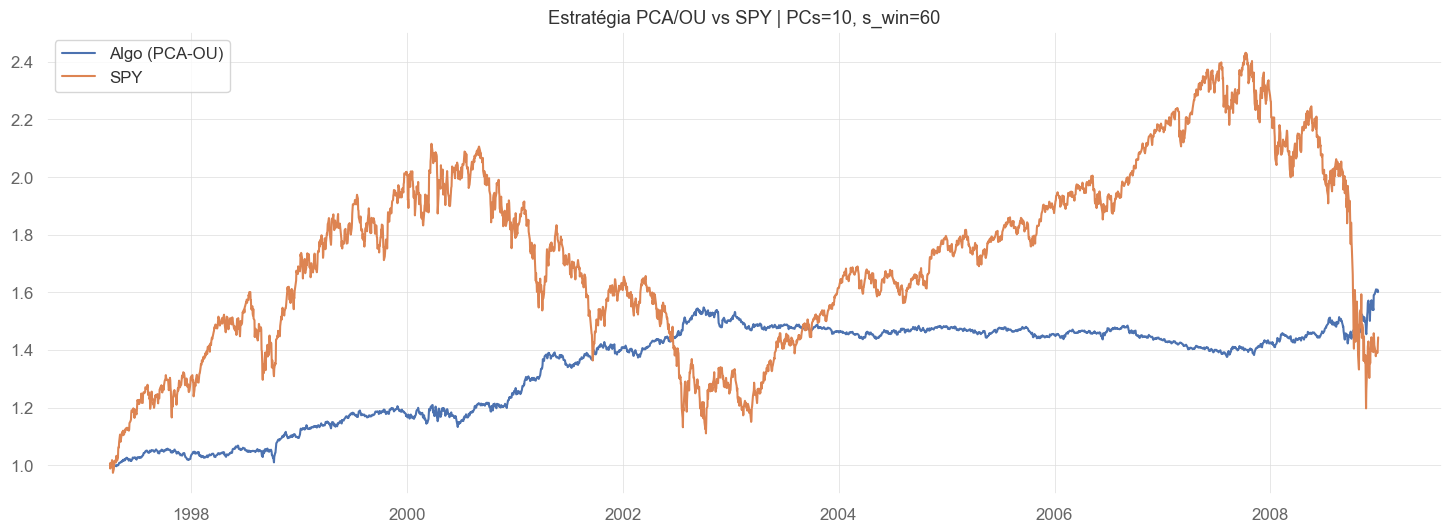

In [14]:
# Rodar experimento 1997 - 2008
returns2 = returns.loc["1997-01-02":"2008-12-31"]
returns_spy2 = returns_spy.loc["1997-01-02":"2008-12-31"]

cum_algo2, s_scores2 = pca_portfolio_spy(
    returns=returns2,
    returns_spy=returns_spy2,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [15]:
# Estatísticas de desempenho
ret_series2 = cum_algo2.pct_change().dropna()
display(stats_from_returns(ret_series2))
cum_algo2

{'CAGR': np.float64(0.04101967661483519),
 'Vol': np.float64(0.05932906266725117),
 'Sharpe': np.float64(0.6913926290205404),
 'MaxDD': np.float64(-0.11102454089458036)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    0.999500
1997-04-04    0.995181
1997-04-07    0.997546
                ...   
2008-12-24    1.610391
2008-12-26    1.603240
2008-12-29    1.609252
2008-12-30    1.600445
2008-12-31    1.603004
Length: 2959, dtype: float64

Tempo : 2009-03-31 00:00:00
Tempo : 2009-04-01 00:00:00
Tempo : 2009-04-02 00:00:00
Tempo : 2009-04-03 00:00:00
Tempo : 2009-04-06 00:00:00
Tempo : 2009-04-07 00:00:00
Tempo : 2009-04-08 00:00:00
Tempo : 2009-04-09 00:00:00
Tempo : 2009-04-13 00:00:00
Tempo : 2009-04-14 00:00:00
Tempo : 2009-04-15 00:00:00
Tempo : 2009-04-16 00:00:00
Tempo : 2009-04-17 00:00:00
Tempo : 2009-04-20 00:00:00
Tempo : 2009-04-21 00:00:00
Tempo : 2009-04-22 00:00:00
Tempo : 2009-04-23 00:00:00
Tempo : 2009-04-24 00:00:00
Tempo : 2009-04-27 00:00:00
Tempo : 2009-04-28 00:00:00
Tempo : 2009-04-29 00:00:00
Tempo : 2009-04-30 00:00:00
Tempo : 2009-05-01 00:00:00
Tempo : 2009-05-04 00:00:00
Tempo : 2009-05-05 00:00:00
Tempo : 2009-05-06 00:00:00
Tempo : 2009-05-07 00:00:00
Tempo : 2009-05-08 00:00:00
Tempo : 2009-05-11 00:00:00
Tempo : 2009-05-12 00:00:00
Tempo : 2009-05-13 00:00:00
Tempo : 2009-05-14 00:00:00
Tempo : 2009-05-15 00:00:00
Tempo : 2009-05-18 00:00:00
Tempo : 2009-05-19 00:00:00
Tempo : 2009-05-20 0

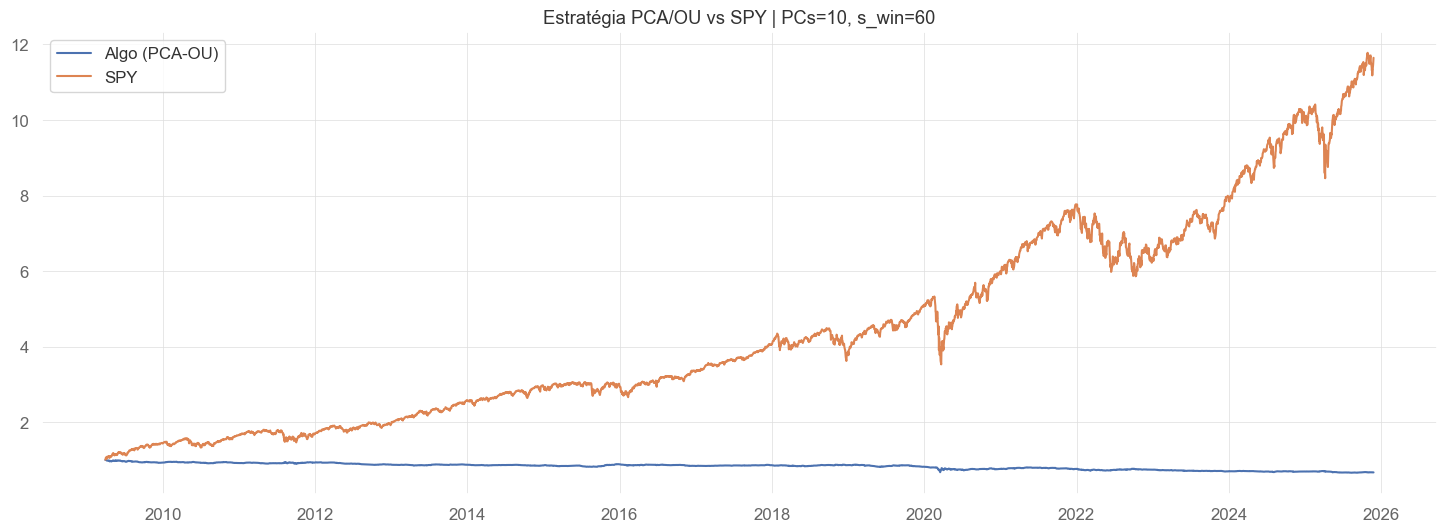

In [ ]:
# Rodar experimento 2009 - 2025
returns3 = returns.loc["2009-01-02":"2025-11-27"]
returns_spy3 = returns_spy.loc["2009-01-02":"2025-11-27"]

cum_algo3, s_scores3 = pca_portfolio_spy(
    returns=returns3,
    returns_spy=returns_spy3,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [ ]:
# Estatísticas de desempenho
ret_series3 = cum_algo3.pct_change().dropna()
display(stats_from_returns(ret_series3))
cum_algo3

{'CAGR': np.float64(-0.02360578102362587),
 'Vol': np.float64(0.05301806123260346),
 'Sharpe': np.float64(-0.44524036667545086),
 'MaxDD': np.float64(-0.3390243737798192)}

Date
2009-03-31    1.000000
2009-04-01    1.000000
2009-04-02    0.999500
2009-04-03    1.000283
2009-04-06    0.995430
                ...   
2025-11-20    0.673321
2025-11-21    0.671372
2025-11-24    0.672192
2025-11-25    0.670147
2025-11-26    0.672072
Length: 4193, dtype: float64

In [4]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

417

In [5]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
    for attempt in range(max_retries):
        try:
            sanitized = ticker.replace(".", "-")
            df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
                             progress=False, threads=False, timeout=30)
            
            if not df.empty:
                return df["Close"]
            else:
                return None
                
        except Exception as e:
            err_msg = str(e)
            print(err_msg)
            
            # Outros erros → re-tenta
            time.sleep(delay)

    return None

start_date = "1997-01-02"
end_date = "2025-11-27"

dict_data2 = {}
data_fail2 = []

for ticker in tickers:
    data_ticker = download_one_ticker(ticker, start_date, end_date)
    print(ticker)
    if data_ticker is not None:
        dict_data2[ticker] = data_ticker
    else:
        data_fail2.append(ticker)

# Construir DataFrames
data2 = pd.concat(dict_data2.values(), axis=1)
data2.columns = dict_data2.keys()

display(data2.head())

# Salvar para uso futuro
# data.to_csv("dados_1997_2025.csv")

MMM
AOS
ABT
ACN
ADBE
AMD
AES
AFL
A
APD
AKAM
ALB
ARE
ALGN
LNT
ALL
GOOGL
GOOG
MO
AMZN
AEE
AEP
AXP
AIG
AMT
AMP
AME
AMGN
APH
ADI
AON
APA
AAPL
AMAT
ACGL
ADM
AJG
AIZ
T
ATO
ADSK
ADP
AZO
AVB
AVY
AXON
BKR
BALL
BAC
BAX
BDX
BRK.B
BBY
TECH
BIIB
BLK
BX
BK
BA
BKNG
BSX
BMY
BR
BRO
BF.B
BLDR
BG
BXP
CHRW
CDNS
CPT
CPB
COF
CAH
KMX
CCL
CAT
CBRE
COR
CNC
CNP
CF
CRL
SCHW
CVX
CMG
CB
CHD
CI
CINF
CTAS
CSCO
C
CLX
CME
CMS
KO
CTSH
CL
CMCSA
CAG
COP
ED
STZ
COO
CPRT
GLW
CSGP
COST
CTRA
CCI
CSX
CMI
CVS
DHR
DRI
DVA
DECK
DE
DAL
DVN
DXCM
DLR
DLTR
D
DPZ
DOV
DHI
DTE
DUK
DD
EMN
ETN
EBAY
ECL
EIX
EW
EA
ELV
EMR
ETR
EOG
EQT
EFX
EQIX
EQR
ERIE
ESS
EL
EG
EVRG
ES
EXC
EXPE
EXPD
EXR
XOM
FFIV
FDS
FICO
FAST
FRT
FDX
FIS
FITB
FSLR
FE
FI
F
BEN
FCX
GRMN
IT
GE
GEN
GD
GIS
GPC
GILD
GPN
GL
GS
HAL
HIG
HAS
DOC
HSIC
HSY
HOLX
HD
HON
HRL
HST
HPQ
HUBB
HUM
HBAN
IBM
IEX
IDXX
ITW
INCY
PODD
INTC
ICE
IFF
IP
IPG
INTU
ISRG
IVZ
IRM
JBHT
JBL
JKHY
J
JNJ
JCI
JPM
K
KEY
KMB
KIM
KLAC
KR
LHX
LH
LRCX
LVS
LDOS
LEN
LII
LLY
LIN
LYV
LKQ
LMT
L
LOW
LULU
MTB
MKTX
MAR
MMC
ML


1 Failed download:
['WBA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2025-11-27) (Yahoo error = "No data found, symbol may be delisted")')


WBA
WMT
DIS
WBD
WM
WAT
WEC
WFC
WELL
WST
WDC
WY
WSM
WMB
WTW
WYNN
XEL
YUM
ZBRA
ZBH


,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,16.411043,1.957846,5.558276,NaN,4.734612,13.5625,7.325693,3.121991,NaN,16.303776,...,16.598818,6.713238,2.756674,4.903797,NaN,NaN,6.733214,NaN,10.333333,NaN
1997-01-03,16.125629,1.941394,5.682406,NaN,4.795901,14.0000,7.305511,3.131094,NaN,16.573009,...,17.317217,6.713238,2.860980,4.988053,NaN,NaN,6.751613,NaN,10.722222,NaN
1997-01-06,16.149412,1.916715,5.613445,NaN,4.964449,14.2500,7.507323,3.167503,NaN,16.662760,...,18.073437,6.802270,2.692104,5.055461,NaN,NaN,6.788405,NaN,10.888889,NaN
1997-01-07,15.959137,1.974299,5.737576,NaN,5.163638,14.9375,7.588045,3.149297,NaN,16.602928,...,17.997807,6.891305,2.771575,5.156571,NaN,NaN,6.825196,NaN,11.888889,NaN
1997-01-08,15.935358,1.966072,5.654820,NaN,5.178962,14.4375,7.648591,3.167503,NaN,16.692667,...,18.716206,6.944724,2.711971,5.207123,NaN,NaN,6.898783,NaN,11.666667,NaN


In [15]:
# Carregar dados
start_date2 = "1997-01-02"
end_date2 = "2025-11-27"

returns2 = data2.pct_change()
returns2.dropna(inplace=True,axis=0, how='all')
returns2.dropna(inplace=True,axis=1, how='any')
returns2 = returns2.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
data_spy2 = yf.download("SPY", start=start_date2, end=end_date2, auto_adjust=True)["Close"]
returns_spy2 = data_spy2.pct_change()
returns_spy2.dropna(inplace=True,axis=0, how='all')
returns_spy2.dropna(inplace=True,axis=1, how='any')

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns2.index     = pd.to_datetime(returns2.index).tz_localize(None)
returns_spy2.index = pd.to_datetime(returns_spy2.index).tz_localize(None)
returns2     = returns2.sort_index()
returns_spy2 = returns_spy2.sort_index()

[*********************100%***********************]  1 of 1 completed


Tempo : 1997-04-01 00:00:00
Tempo : 1997-04-02 00:00:00
Tempo : 1997-04-03 00:00:00
Tempo : 1997-04-04 00:00:00
Tempo : 1997-04-07 00:00:00
Tempo : 1997-04-08 00:00:00
Tempo : 1997-04-09 00:00:00
Tempo : 1997-04-10 00:00:00
Tempo : 1997-04-11 00:00:00
Tempo : 1997-04-14 00:00:00
Tempo : 1997-04-15 00:00:00
Tempo : 1997-04-16 00:00:00
Tempo : 1997-04-17 00:00:00
Tempo : 1997-04-18 00:00:00
Tempo : 1997-04-21 00:00:00
Tempo : 1997-04-22 00:00:00
Tempo : 1997-04-23 00:00:00
Tempo : 1997-04-24 00:00:00
Tempo : 1997-04-25 00:00:00
Tempo : 1997-04-28 00:00:00
Tempo : 1997-04-29 00:00:00
Tempo : 1997-04-30 00:00:00
Tempo : 1997-05-01 00:00:00
Tempo : 1997-05-02 00:00:00
Tempo : 1997-05-05 00:00:00
Tempo : 1997-05-06 00:00:00
Tempo : 1997-05-07 00:00:00
Tempo : 1997-05-08 00:00:00
Tempo : 1997-05-09 00:00:00
Tempo : 1997-05-12 00:00:00
Tempo : 1997-05-13 00:00:00
Tempo : 1997-05-14 00:00:00
Tempo : 1997-05-15 00:00:00
Tempo : 1997-05-16 00:00:00
Tempo : 1997-05-19 00:00:00
Tempo : 1997-05-20 0

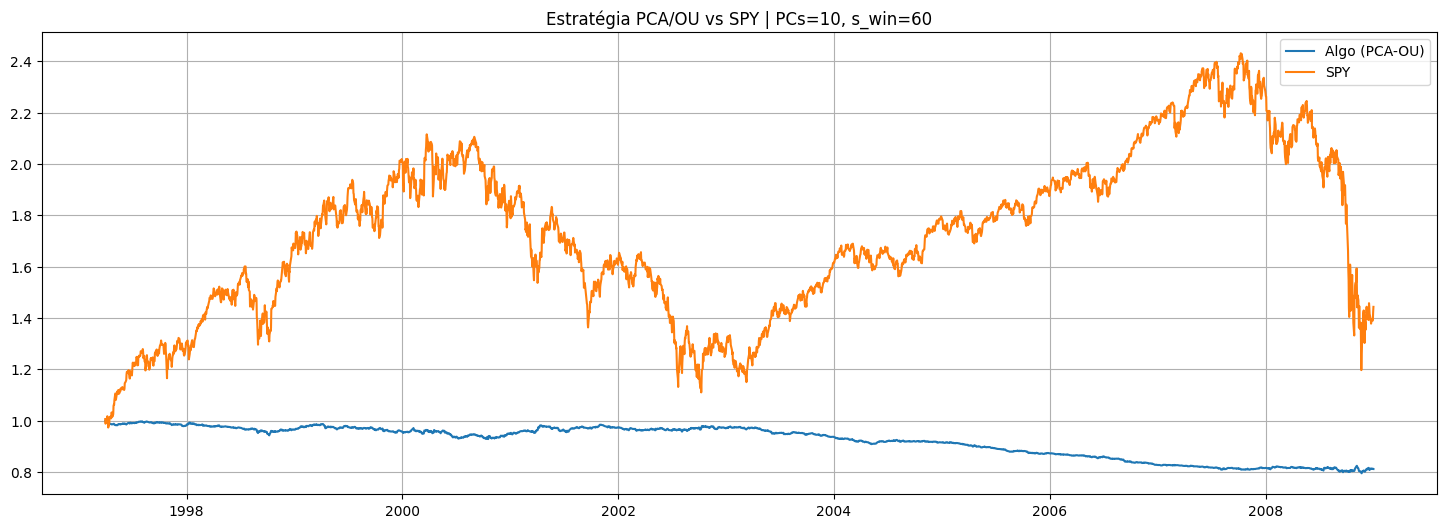

In [8]:
# Rodar experimento 1998 - 2008
returns4 = returns2.loc["1997-01-02":"2008-12-31"]
returns_spy4 = returns_spy2.loc["1997-01-02":"2008-12-31"]

cum_algo4, s_scores4 = pca_portfolio_spy(
    returns=returns4,
    returns_spy=returns_spy4,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [9]:
# Estatísticas de desempenho
ret_series4 = cum_algo4.pct_change().dropna()
display(stats_from_returns(ret_series4))
cum_algo4

{'CAGR': np.float64(-0.017617207972736026),
 'Vol': np.float64(0.02466308511801952),
 'Sharpe': np.float64(-0.7143148510591003),
 'MaxDD': np.float64(-0.2047769858286803)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    0.999500
1997-04-04    0.996642
1997-04-07    0.995599
                ...   
2008-12-24    0.813456
2008-12-26    0.812606
2008-12-29    0.813307
2008-12-30    0.811752
2008-12-31    0.811691
Length: 2959, dtype: float64

Tempo : 2009-03-31 00:00:00
Tempo : 2009-04-01 00:00:00
Tempo : 2009-04-02 00:00:00
Tempo : 2009-04-03 00:00:00
Tempo : 2009-04-06 00:00:00
Tempo : 2009-04-07 00:00:00
Tempo : 2009-04-08 00:00:00
Tempo : 2009-04-09 00:00:00
Tempo : 2009-04-13 00:00:00
Tempo : 2009-04-14 00:00:00
Tempo : 2009-04-15 00:00:00
Tempo : 2009-04-16 00:00:00
Tempo : 2009-04-17 00:00:00
Tempo : 2009-04-20 00:00:00
Tempo : 2009-04-21 00:00:00
Tempo : 2009-04-22 00:00:00
Tempo : 2009-04-23 00:00:00
Tempo : 2009-04-24 00:00:00
Tempo : 2009-04-27 00:00:00
Tempo : 2009-04-28 00:00:00
Tempo : 2009-04-29 00:00:00
Tempo : 2009-04-30 00:00:00
Tempo : 2009-05-01 00:00:00
Tempo : 2009-05-04 00:00:00
Tempo : 2009-05-05 00:00:00
Tempo : 2009-05-06 00:00:00
Tempo : 2009-05-07 00:00:00
Tempo : 2009-05-08 00:00:00
Tempo : 2009-05-11 00:00:00
Tempo : 2009-05-12 00:00:00
Tempo : 2009-05-13 00:00:00
Tempo : 2009-05-14 00:00:00
Tempo : 2009-05-15 00:00:00
Tempo : 2009-05-18 00:00:00
Tempo : 2009-05-19 00:00:00
Tempo : 2009-05-20 0

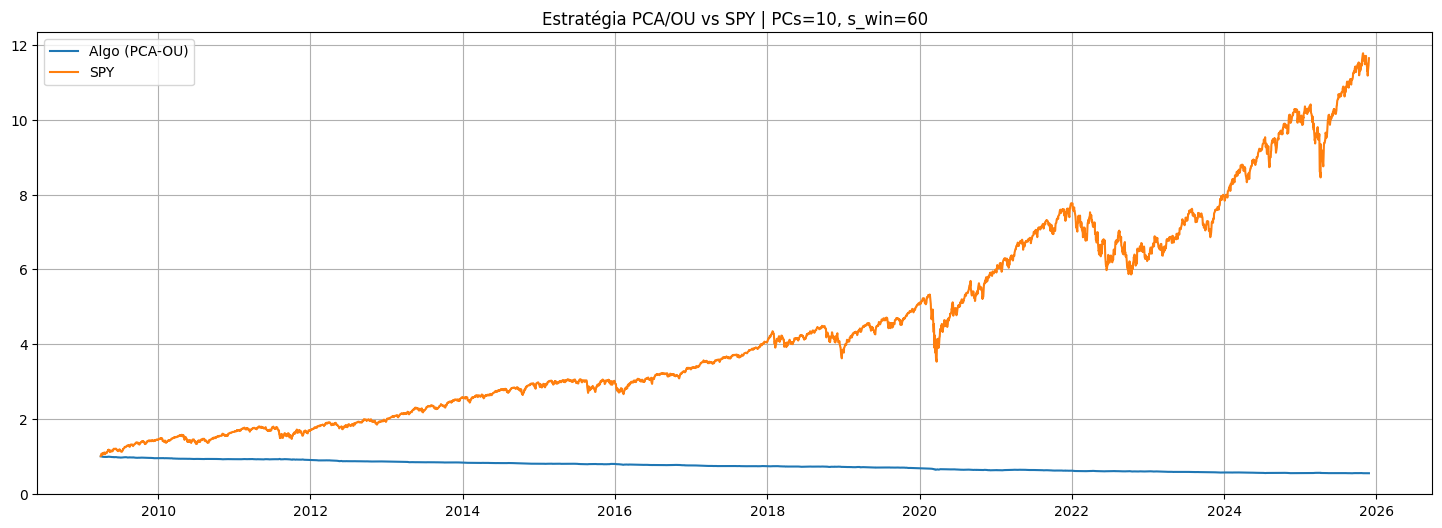

In [10]:
# Rodar experimento 2009 - 2025
returns3 = returns2.loc["2009-01-02":"2025-11-27"]
returns_spy3 = returns_spy2.loc["2009-01-02":"2025-11-27"]

cum_algo3, s_scores3 = pca_portfolio_spy(
    returns=returns3,
    returns_spy=returns_spy3,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [11]:
# Estatísticas de desempenho
ret_series3 = cum_algo3.pct_change().dropna()
display(stats_from_returns(ret_series3))
cum_algo3

{'CAGR': np.float64(-0.035410974589052735),
 'Vol': np.float64(0.02059595539251999),
 'Sharpe': np.float64(-1.7193169199576555),
 'MaxDD': np.float64(-0.45220597152344544)}

Date
2009-03-31    1.000000
2009-04-01    1.000000
2009-04-02    0.999500
2009-04-03    0.998803
2009-04-06    0.996751
                ...   
2025-11-20    0.549229
2025-11-21    0.548871
2025-11-24    0.548611
2025-11-25    0.548276
2025-11-26    0.548954
Length: 4193, dtype: float64

In [ ]:
#pip install quantstats

In [13]:
import quantstats as qs

qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
